<a href="https://colab.research.google.com/github/Abhishek4852/gold_price_prediction/blob/main/visualization/colab_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (3666, 47)

Columns: ['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']

Missing values:
 date                  0
sp500 open            0
sp500 high            0
sp500 low             0
sp500 close           0
sp500 volume          0
sp500 high-low        0
nasdaq open           0
nasdaq high           0
nasdaq low            0
nasdaq

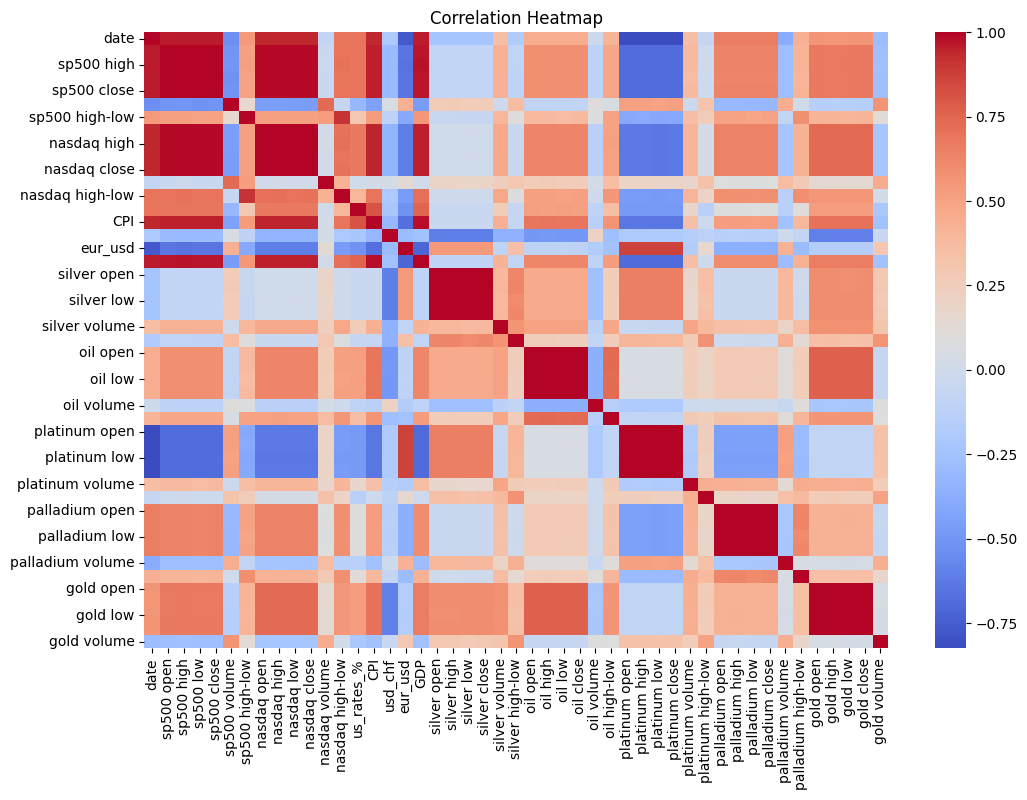

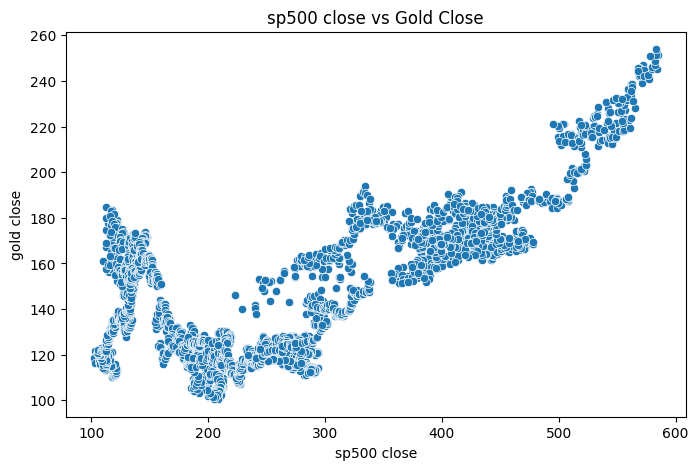

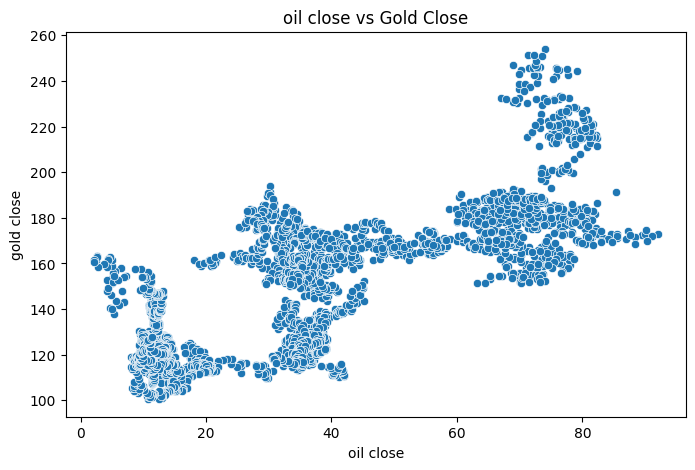

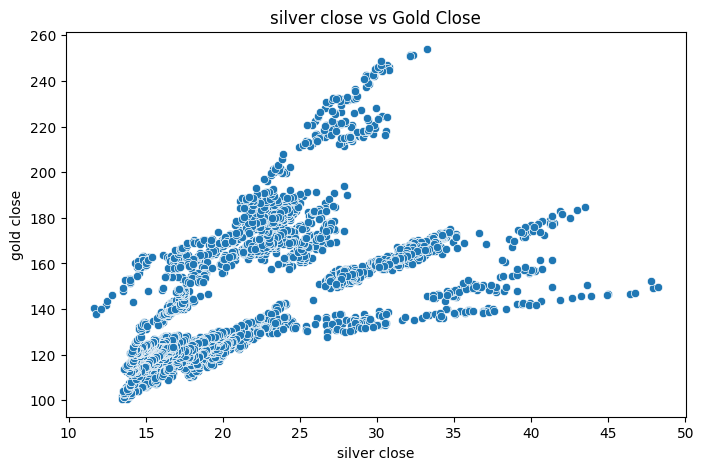

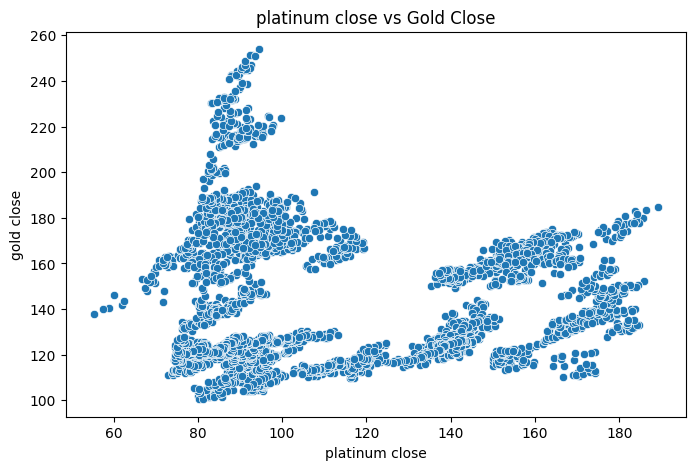

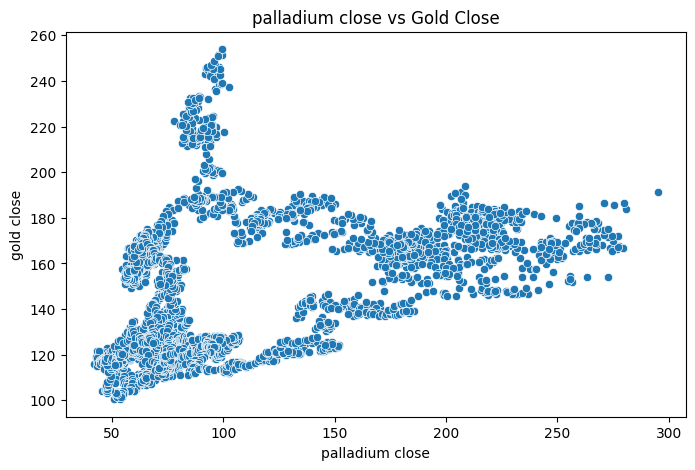

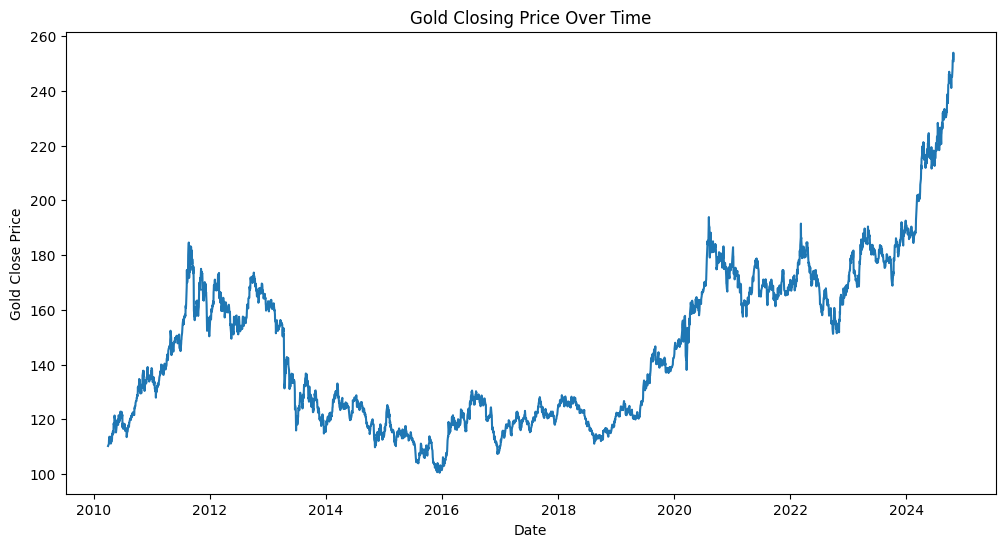

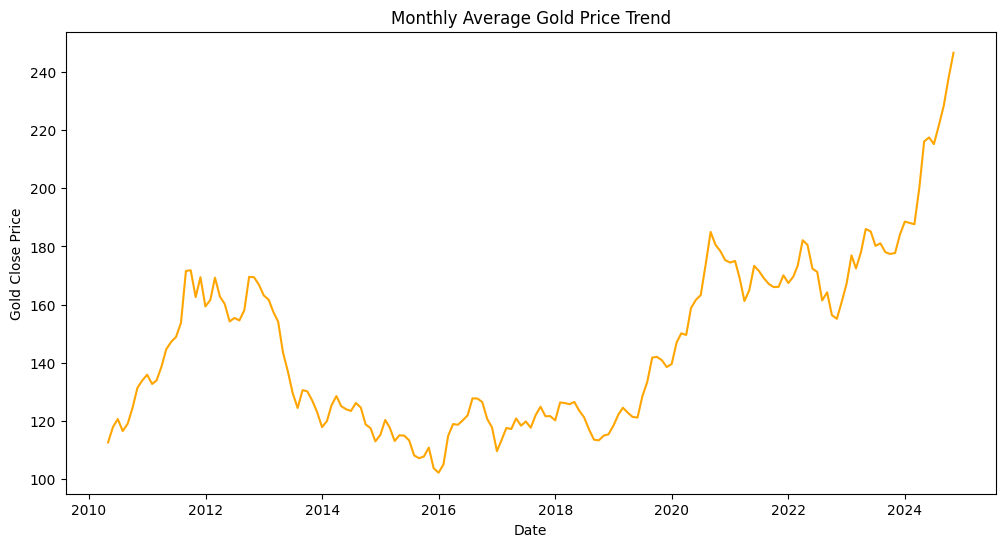


✅ Data analysis completed successfully!


In [2]:
# ==========================================================
# 1_data_analysis.ipynb
# Purpose: Explore and visualize gold price data
# ==========================================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv("/content/processed_gold_data.csv")
df['date'] = pd.to_datetime(df['date'])

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())

# ----------------------------------------------
# 1️⃣ Correlation Analysis
# ----------------------------------------------
gold_corr = df.corr()['gold close'].sort_values(ascending=False)
print("\nCorrelation with Gold Close:\n", gold_corr)

# Heatmap for all features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------------------------
# 2️⃣ Visualize top correlated features
# ----------------------------------------------
top_features = ['sp500 close', 'oil close', 'silver close', 'platinum close', 'palladium close']

for feature in top_features:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=feature, y='gold close', data=df)
    plt.title(f"{feature} vs Gold Close")
    plt.show()

# ----------------------------------------------
# 3️⃣ Time Series Trend
# ----------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['gold close'])
plt.title("Gold Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Close Price")
plt.show()

# Monthly trend
df_monthly = df.resample('ME', on='date').mean()
plt.figure(figsize=(12,6))
plt.plot(df_monthly.index, df_monthly['gold close'], color='orange')
plt.title("Monthly Average Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("Gold Close Price")
plt.show()

print("\n✅ Data analysis completed successfully!")



Linear Regression
R²: 0.8713
MAE: 7.6714
RMSE: 10.3664

Polynomial Regression (Degree 2)
R²: 0.9596
MAE: 4.3813
RMSE: 5.8061

Ridge Regression
R²: 0.8713
MAE: 7.6715
RMSE: 10.3663

Lasso Regression
R²: 0.8713
MAE: 7.6715
RMSE: 10.3663

Random Forest Regression
R²: 0.9951
MAE: 1.2357
RMSE: 2.0220


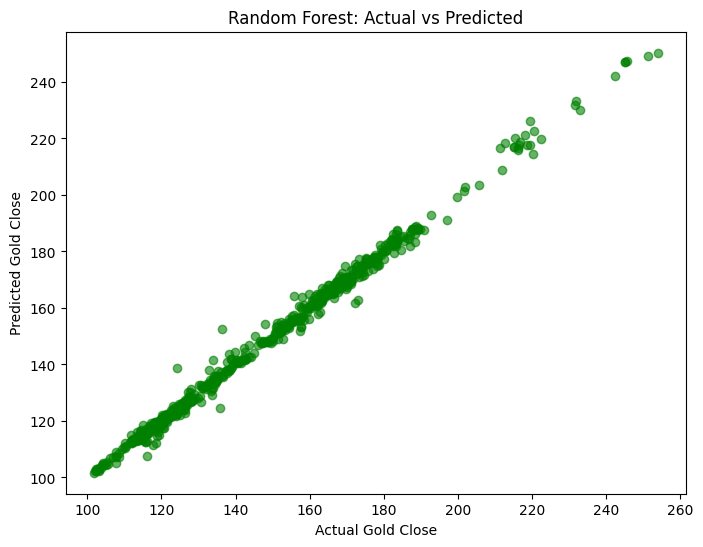


✅ Model training and evaluation completed successfully!


In [3]:
# ==========================================================
# 2_model_building.ipynb
# Purpose: Train and evaluate multiple regression models
# ==========================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load processed data
df = pd.read_csv("/content/processed_gold_data.csv")

# Select top features (based on correlation analysis)
top_features = ['sp500 close', 'oil close', 'silver close', 'platinum close', 'palladium close']
X = df[top_features]
y = df['gold close']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define evaluation function
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name}")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

# ----------------------------------------------
# 1️⃣ Linear Regression
# ----------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)
evaluate_model("Linear Regression", y_test, y_pred_lr)

# ----------------------------------------------
# 2️⃣ Polynomial Regression
# ----------------------------------------------
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_pred_poly = poly_model.predict(X_poly_test)
evaluate_model("Polynomial Regression (Degree 2)", y_test, y_pred_poly)

# ----------------------------------------------
# 3️⃣ Ridge Regression
# ----------------------------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

# ----------------------------------------------
# 4️⃣ Lasso Regression
# ----------------------------------------------
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)

# ----------------------------------------------
# 5️⃣ Random Forest Regression
# ----------------------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model("Random Forest Regression", y_test, y_pred_rf)

# ----------------------------------------------
# 6️⃣ Compare Actual vs Predicted for Best Model
# ----------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.xlabel("Actual Gold Close")
plt.ylabel("Predicted Gold Close")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

print("\n✅ Model training and evaluation completed successfully!")
